<a href="https://colab.research.google.com/github/NguyenTien-beep/Study_In_DPL_302/blob/main/Report_01/DPL_Nhom9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = np.load('/content/pems04.npz')
print(data.files)
traffic = data['data']
print("Shape:", traffic.shape)

['data']
Shape: (16992, 307, 3)


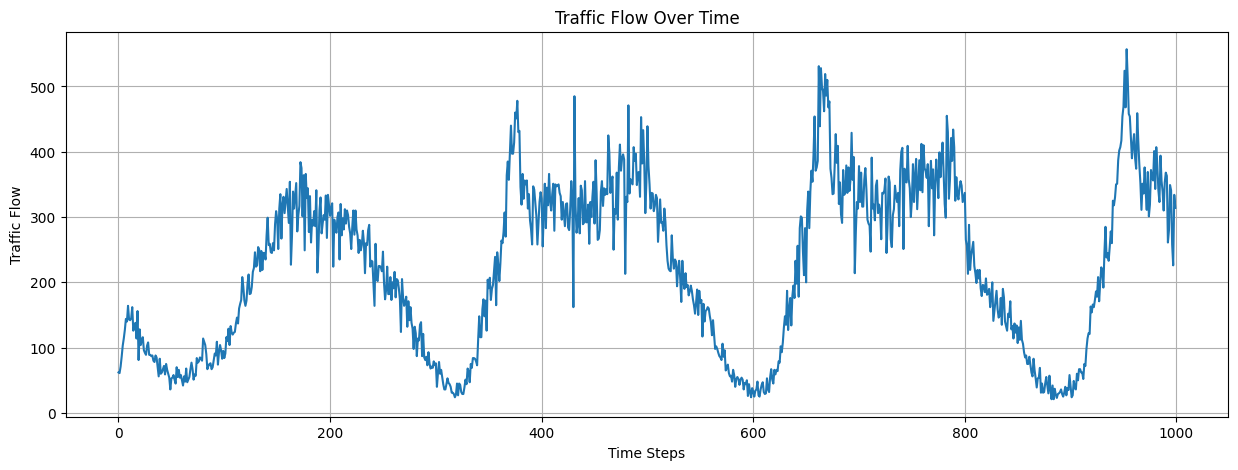

In [24]:
flow = traffic[:, :, 0]

sensor_id = 0

plt.figure(figsize=(15,5))
plt.plot(flow[:1000, sensor_id])

plt.title("Traffic Flow Over Time")
plt.xlabel("Time Steps")
plt.ylabel("Traffic Flow")

plt.grid(True)
plt.show()

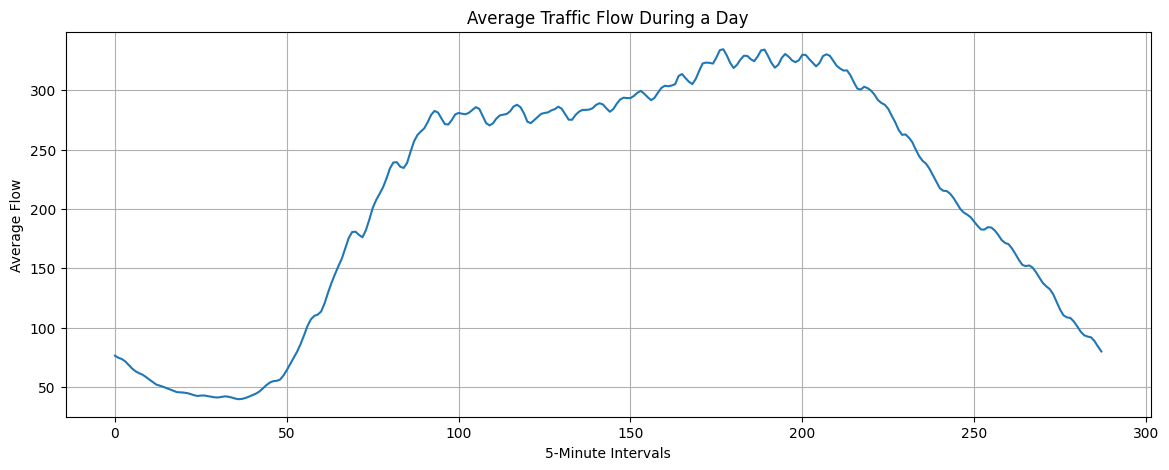

In [25]:
avg_flow = flow.mean(axis=1)

hours = np.arange(len(avg_flow)) % 288

hourly_avg = []

for h in range(288):
    hourly_avg.append(avg_flow[hours == h].mean())

plt.figure(figsize=(14,5))
plt.plot(hourly_avg)

plt.title("Average Traffic Flow During a Day")
plt.xlabel("5-Minute Intervals")
plt.ylabel("Average Flow")

plt.grid(True)
plt.show()

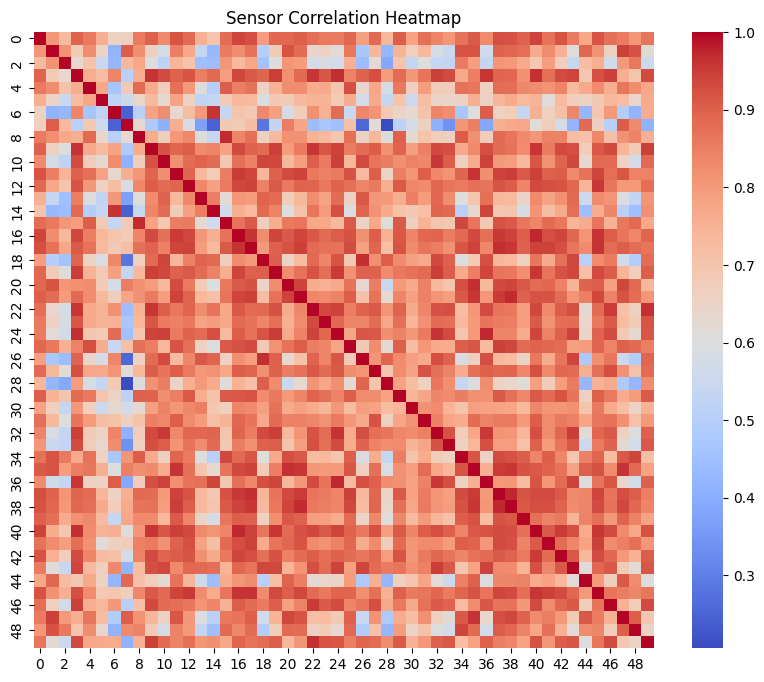

In [26]:
sample = flow[:500]

corr_matrix = np.corrcoef(sample.T)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix[:50, :50],
    cmap='coolwarm'
)

plt.title("Sensor Correlation Heatmap")
plt.show()

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

flow = traffic[:, :, 0]

sensor_data = flow[:, 0]

scaler = MinMaxScaler()

sensor_data = scaler.fit_transform(
    sensor_data.reshape(-1,1)
)

sequence_length = 12

X = []
y = []

for i in range(len(sensor_data) - sequence_length):
    X.append(sensor_data[i:i+sequence_length])
    y.append(sensor_data[i+sequence_length])

X = np.array(X)
y = np.array(y)

train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

class GRUModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.gru = nn.GRU(
            input_size=1,
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self, x):

        out, _ = self.gru(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

model = GRUModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

losses = []

epochs = 20

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for batch_x, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.5f}")

Epoch 1, Loss: 0.02009
Epoch 2, Loss: 0.00393
Epoch 3, Loss: 0.00383
Epoch 4, Loss: 0.00377
Epoch 5, Loss: 0.00383
Epoch 6, Loss: 0.00379
Epoch 7, Loss: 0.00375
Epoch 8, Loss: 0.00373
Epoch 9, Loss: 0.00378
Epoch 10, Loss: 0.00377
Epoch 11, Loss: 0.00377
Epoch 12, Loss: 0.00374
Epoch 13, Loss: 0.00369
Epoch 14, Loss: 0.00375
Epoch 15, Loss: 0.00372
Epoch 16, Loss: 0.00369
Epoch 17, Loss: 0.00369
Epoch 18, Loss: 0.00367
Epoch 19, Loss: 0.00367
Epoch 20, Loss: 0.00364


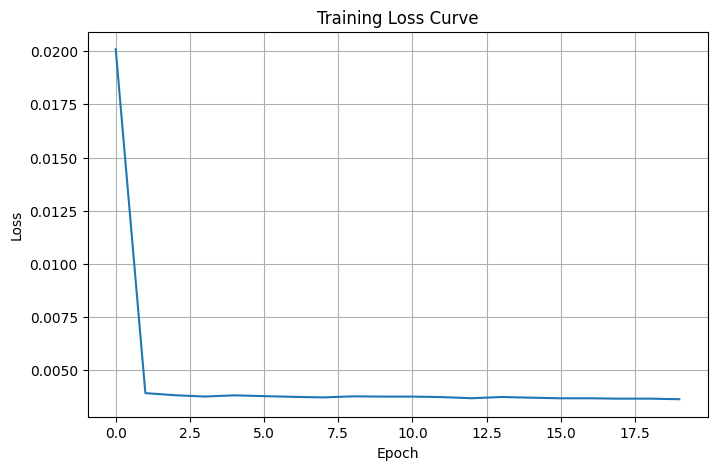

In [28]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

model.eval()

with torch.no_grad():
    predictions = model(X_test)

predictions = predictions.numpy()
y_true = y_test.numpy()

mae = mean_absolute_error(
    y_true,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        predictions
    )
)

mape = mean_absolute_percentage_error(
    y_true,
    predictions
)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)  # Hiển thị dưới dạng thập phân (ví dụ: 0.05 tương đương 5%)
# Hoặc in dưới dạng phần trăm cho dễ nhìn:
# print(f"MAPE: {mape * 100:.2f}%")

MAE: 0.0432857982814312
RMSE: 0.060586898788091384
MAPE: 0.1272745430469513


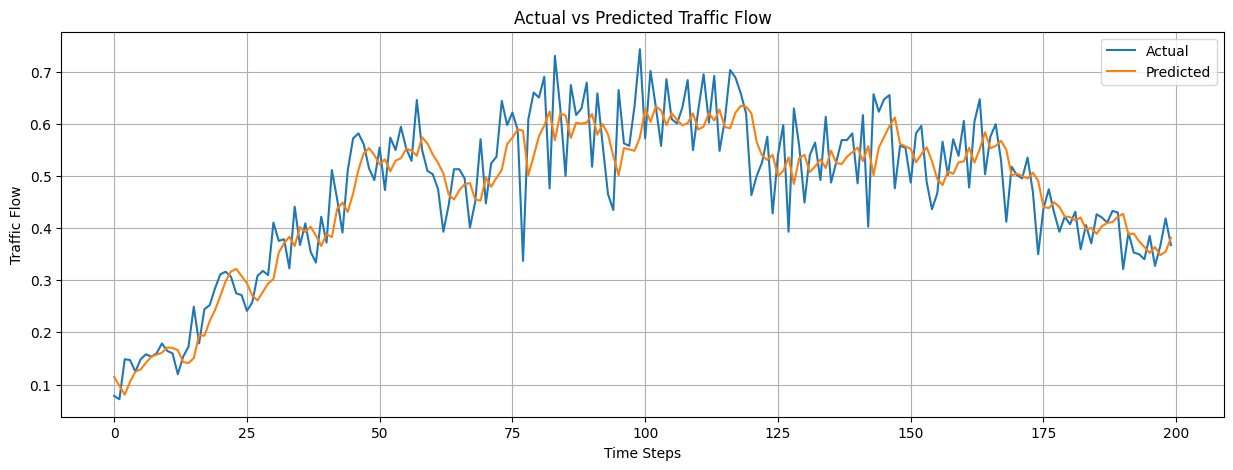

In [30]:
plt.figure(figsize=(15,5))

plt.plot(
    y_true[:200],
    label='Actual'
)

plt.plot(
    predictions[:200],
    label='Predicted'
)

plt.title("Actual vs Predicted Traffic Flow")

plt.xlabel("Time Steps")
plt.ylabel("Traffic Flow")

plt.legend()

plt.grid(True)

plt.show()